<a href="https://colab.research.google.com/github/chatterdivya/counts-of-employe/blob/main/Colab%20Notebook/Soil_Fertility_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 <h1>Including Necessary libraries</h1>

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

<h1>Importing Dataset</h1>

In [11]:
# reading data from excel sheet
import pandas as pd
soil_data = pd.read_excel('soil_data.xlsx',header=None)

# Viewing first few rows of dataset
soil_data

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,Metadata - Soils Collection and Lab (Kuo) Anal...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Sample,DIR.,INT/EXT,Sub- Sample #,Date,Time,Latitude,Longitude,Slope,Aspect,...,SO4-S (ppm),B (ppm),Organic Matter %,pH,Zn (ppm),Cu (ppm),Fe (ppm),Ca (meq/100g),Mg (meq/100g),Na (meq/100g)
2,1,NW,INT,1,2012-06-04 00:00:00,13:50:00,N25.77485,W171.73539,2,92,...,12,0.71,0.96,7.8,1.7,0.3,4,6.6,0.8,0.12
3,2,NW,INT,2,2012-06-04 00:00:00,14:43:00,N25.77774,W171.73643,1,167,...,7,0.27,0.3,8.2,0.8,0.1,1,5,0.5,0.07
4,3,NW,INT,3,2012-06-04 00:00:00,14:10:00,N25.77628,W171.73480,5,75,...,10,0.56,0.62,7.9,1.4,0.2,2,5.2,0.4,0.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
417,Longitude,Longitude for sample location in decimal degrees,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
418,Slope,"Slope of the ground at sample location, in deg...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
419,Aspect,"Directoin the slope face at sample location, i...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
420,% Veg. Cover,Percent vegetative cover of the 102m area surr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
from google.colab import files
uploaded = files.upload()

Saving soil_data.xlsx to soil_data.xlsx


In [12]:
# removing unnecessary columns and rows that do not contains data
soil_data = soil_data.drop(np.arange(410,422),axis=0)
soil_data = soil_data.drop([0,1],axis=0)
soil_data = soil_data.drop(np.arange(0,10),axis=1)

#renaming column names and units of each attributes
column_names = ['Vegetation Cover','NO3','NH4','P','K','SO4',
                'B','Organic Matter','pH','Zn','Cu','Fe','Ca','Mg','Na']
attribute_units = ['%age','ppm','ppm','ppm','ppm','ppm','ppm',
                "%age",'pH','ppm','ppm','ppm','meq/100g','meq/100g','meq/100g']


#assuring length of column and attribute_units is same
assert(len(attribute_units) == len(column_names))


#creating new dataframe with column name
soil_data = pd.DataFrame(soil_data.values,columns=column_names)

#viewing final data frame
soil_data.head()

,Vegetation Cover,NO3,NH4,P,K,SO4,B,Organic Matter,pH,Zn,Cu,Fe,Ca,Mg,Na
0,100,23,2.25,101,32,12,0.71,0.96,7.8,1.7,0.3,4,6.6,0.8,0.12
1,95,6,0.75,58,10,7,0.27,0.3,8.2,0.8,0.1,1,5,0.5,0.07
2,98,7.25,1,115,8,10,0.56,0.62,7.9,1.4,0.2,2,5.2,0.4,0.04
3,100,21,1.25,130,30,13,0.78,1.04,7.9,1.8,0.3,2,6.1,0.7,0.1
4,15,1.75,0.5,17,4,6,0.25,0.1,8.8,0.3,0.1,1,4.7,0.5,0.1


In [13]:
soil_data.isna().sum()

,0
Vegetation Cover,13
NO3,14
NH4,3
P,6
K,5
SO4,1
B,3
Organic Matter,2
pH,3
Zn,5


In [ ]:
soil_data.fillna(0)

In [14]:
from numpy import nan
from numpy import isnan
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=nan, strategy='median')
# transform the dataset
transformed_values = imputer.fit_transform(soil_data)
# count the number of NaN values in each column
print('Missing: %d' % isnan(transformed_values).sum())

Missing: 0


In [16]:
soil_data= pd.DataFrame(transformed_values,columns=column_names)
soil_data.isna().sum()

,0
Vegetation Cover,0
NO3,0
NH4,0
P,0
K,0
SO4,0
B,0
Organic Matter,0
pH,0
Zn,0


<h1>Saving the Preprocessed Data set</h1>

In [15]:
soil_data.to_csv(r'processed_data_set.csv', index=False)

In [17]:
# printing minimum values for each column in the dataset
min_values=soil_data.min()
print(min_values)

Vegetation Cover     1.00
NO3                  0.25
NH4                  0.25
P                   10.00
K                    4.00
SO4                  4.00
B                    0.07
Organic Matter       0.01
pH                   7.40
Zn                   0.10
Cu                   0.10
Fe                   1.00
Ca                   4.20
Mg                   0.30
Na                   0.03
dtype: float64


In [18]:
# printing maximum values for each column in the dataset
max_values=soil_data.max()
print(max_values)

Vegetation Cover    100.00
NO3                 633.75
NH4                  14.25
P                   171.00
K                   164.00
SO4                 258.00
B                    17.46
Organic Matter        4.46
pH                    8.80
Zn                   10.00
Cu                    1.30
Fe                    4.00
Ca                   12.50
Mg                    6.30
Na                    8.22
dtype: float64


<h1>Data Visualization</h1>

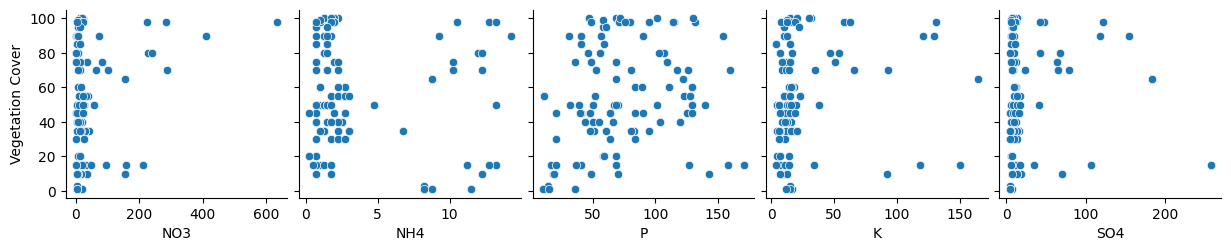

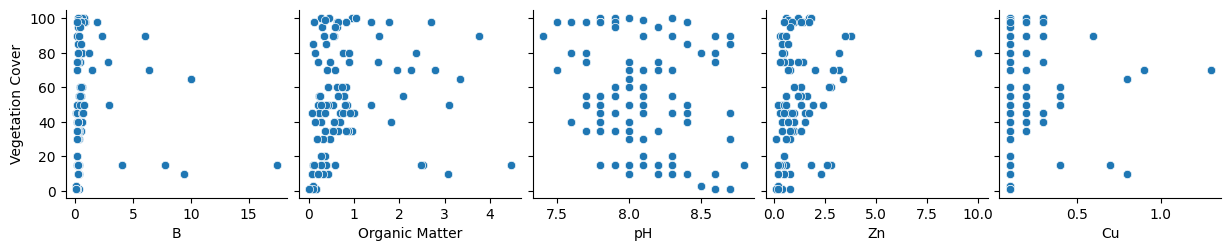

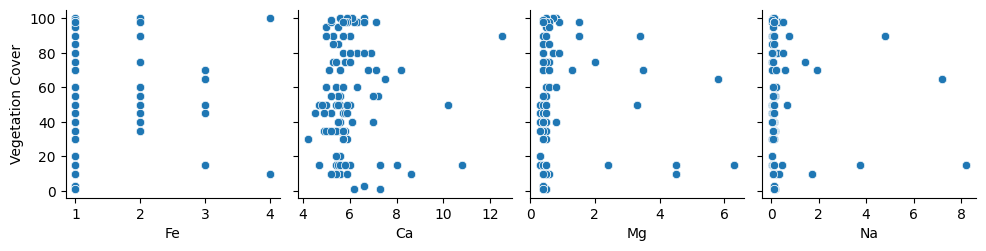

<Axes: >

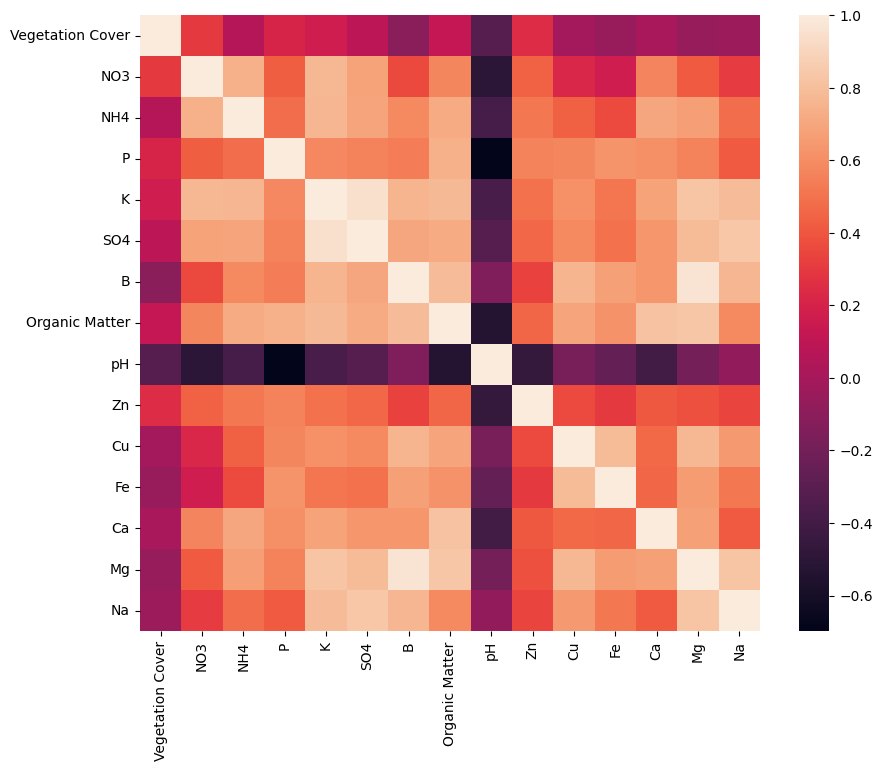

In [19]:
import seaborn as sns

#pair plots
pairplot1 = sns.pairplot(soil_data,x_vars=soil_data.columns[1:6],y_vars=['Vegetation Cover'])
plt.show()

pairplot2 = sns.pairplot(soil_data,x_vars=soil_data.columns[6:11],y_vars=['Vegetation Cover'])
plt.show()

pairplot3 = sns.pairplot(soil_data,x_vars=soil_data.columns[11:15],y_vars=['Vegetation Cover'])
plt.show()

# getting coeralation values
values = soil_data.corr()
# plotting values
plt.figure(figsize=(10,8))
sns.heatmap(values,annot=False)

<h1>Visualizing result of corelation matrix</h1>

It is clear from above matrix that Vegetation Cover is highly depends on pH.

 <h1>Reading processed data</h1>

In [20]:
import pandas as pd
import numpy as np


X, Y = soil_data[soil_data.columns[1:]], soil_data['Vegetation Cover']


print(X[:10])
print(X)
# Normalizing data
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X, Y = scaler.fit_transform(X.values), scaler.fit_transform(Y.values.reshape(-1,1))
print(X[0])

     NO3   NH4      P     K   SO4     B  Organic Matter   pH   Zn   Cu   Fe  \
0  23.00  2.25  101.0  32.0  12.0  0.71            0.96  7.8  1.7  0.3  4.0   
1   6.00  0.75   58.0  10.0   7.0  0.27            0.30  8.2  0.8  0.1  1.0   
2   7.25  1.00  115.0   8.0  10.0  0.56            0.62  7.9  1.4  0.2  2.0   
3  21.00  1.25  130.0  30.0  13.0  0.78            1.04  7.9  1.8  0.3  2.0   
4   1.75  0.50   17.0   4.0   6.0  0.25            0.10  8.8  0.3  0.1  1.0   
5   2.00  0.75   40.0   8.0   6.0  0.24            0.22  8.3  0.9  0.1  1.0   
6   1.50  0.25   21.0  12.0   5.0  0.20            0.08  8.7  0.3  0.1  1.0   
7  14.75  0.75   53.0  12.0   8.0  0.18            0.41  8.3  0.8  0.1  1.0   
8  12.75  2.00   72.0  15.0  10.0  0.64            0.45  8.0  1.2  0.2  2.0   
9  18.50  1.75   47.0  21.0   7.0  0.29            0.28  8.3  0.6  0.1  1.0   

    Ca   Mg    Na  
0  6.6  0.8  0.12  
1  5.0  0.5  0.07  
2  5.2  0.4  0.04  
3  6.1  0.7  0.10  
4  4.7  0.5  0.10  
5  4.9  0.

<h1>Implementing ML models</h1>

<h3>Useful functions to implement a general model</h3>

In [23]:
from sklearn.metrics import r2_score

def train(model, X, Y):
    model.fit(X,Y)
    return model

def print_metrics(model, X, Y):

    # predicted test data
    y_pred = model.predict(X)

    # Mean square Error
    mean_square_error = np.sum((y_pred-Y)**2)/len(y_pred)
    print('Mean Square Error : ', mean_square_error)

    # Root Mean Square Error
    print('Root Mean Square Error : ', mean_square_error**0.5)

    # Mean absolute Error
    print('Mean Absolute Error : ', np.abs(Y - y_pred).sum()/len(y_pred))

    # R2 Score
    print('R2 Score : ', r2_score(Y, y_pred))

    print('Accuracy : ',model.score(X,Y))


<h3>Spliting data into train and test set</h3>

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.10, random_state=43)
print(X_train)

[[0.04143646 0.17857143 0.33540373 ... 0.18072289 0.01666667 0.002442  ]
 [0.24309392 0.60714286 0.69565217 ... 0.39759036 0.91666667 0.87545788]
 [0.37963694 0.85714286 0.57763975 ... 0.3253012  0.1        0.05494505]
 ...
 [0.04459353 0.46428571 0.52795031 ... 0.18072289 0.03333333 0.01098901]
 [0.02209945 0.         0.30434783 ... 0.14457831 0.         0.001221  ]
 [0.06156275 0.10714286 0.26086957 ... 0.15662651 0.03333333 0.00610501]]


<h2>Implement Linear Model</h2>


In [29]:
# Import libraries
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pickle

# Create model
linearModel = LinearRegression()

# Train model
linearModel.fit(X_train, Y_train)

# Prediction
Y_pred = linearModel.predict(X_test)

# Metrics
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

# Print results
print("Mean Square Error :", mse)
print("Root Mean Square Error :", rmse)
print("Mean Absolute Error :", mae)
print("R2 Score :", r2)
print("Accuracy :", r2)

# Save model
with open('Linear_Model.pkl', 'wb') as f:
    pickle.dump(linearModel, f)

print("Model saved successfully")

Mean Square Error : 0.07408422339697683
Root Mean Square Error : 0.2721841718340301
Mean Absolute Error : 0.2404848507569429
R2 Score : 0.12946778762096356
Accuracy : 0.12946778762096356
Model saved successfully


In [30]:
!pip install opencv-python

In [31]:
from google.colab import files
uploaded = files.upload()

Saving soil.jpg to soil.jpg


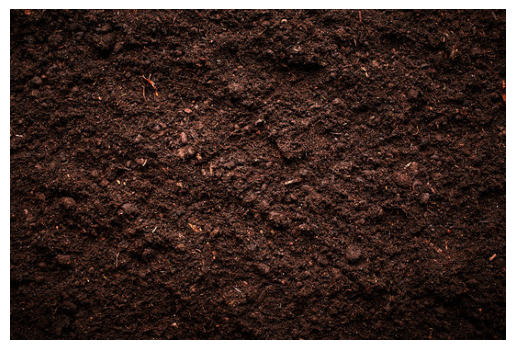

In [32]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('soil.jpg')

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.show()

In [33]:
import numpy as np

avg_color = img.mean(axis=0).mean(axis=0)

print(avg_color)

[47.36728909 28.33559156 22.92483025]


In [35]:
from sklearn.tree import DecisionTreeRegressor

# Create model
treeRegressor = DecisionTreeRegressor(
    criterion='squared_error',
    max_depth=8,
    min_samples_leaf=5
)

# Train model
treeRegressor.fit(X_train, Y_train)

DecisionTreeRegressor(max_depth=8, min_samples_leaf=5)

<h2>Implement SVR</h2>

In [37]:
import numpy as np

# RGB values from image
r = avg_color[0]
g = avg_color[1]
b = avg_color[2]

# Create 14 features
features = np.array([[r, g, b, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

# Predict
prediction = treeRegressor.predict(features)

print("Soil Fertility Prediction:", prediction)

Soil Fertility Prediction: [0.97979798]


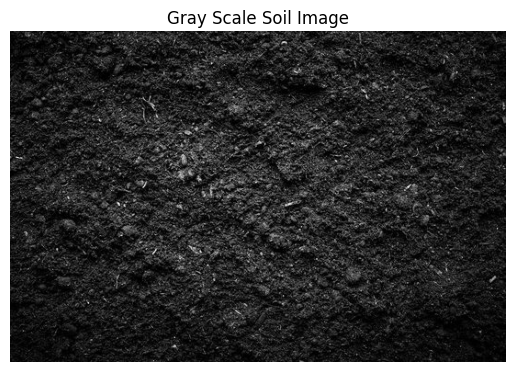

In [38]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Gray Scale Soil Image")
plt.axis('off')
plt.show()

<h2>DecisionTreeRegressor</h2>

<h2>Implement Random Forest Regressor</h2>

**<h1>Results**
<h3>The above models worked differently, the order of their performance is given below (top-to-bottom i.e high-to-low)</h3>

1. Random Forest Regression


2. Decision Tree Regression


3. Support Vector Regression(RBF)


4. Support Vector Regression(Poly)


5. Support Vector Regression(Linear)


6. Linear Regression
